In [ ]:
from typing import Annotated, List, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

import os

# 使用指定配置初始化LLM
llm = ChatOpenAI(
    base_url=os.getenv("LLM_BASE_URL"),
    api_key=os.getenv("LLM_API_KEY"),
    model='qwen-plus-latest',
)

# 定义计划的结构化输出
class Task(BaseModel):
    id: str = Field(description="任务的唯一标识符")
    task: str = Field(description="要执行的任务描述")
    tool: Optional[str] = Field(default=None, description="此任务需要的工具名称(如果有)")

    class Config:
        extra = "ignore"

class Plan(BaseModel):
    plan: List[Task] = Field(description="按顺序执行的任务列表")

    class Config:
        extra = "ignore"

# 定义状态结构
class State(TypedDict):
    input: str
    plan: List[Task]
    current_task_index: int
    results: Annotated[list, add_messages]
    final_answer: str

# 创建图
graph_builder = StateGraph(State)

# 生成计划的规划器节点
planner_llm = llm.with_structured_output(Plan)

def planner_node(state: State):
    """基于输入生成计划"""
    system_msg = SystemMessage(content="""
    你是一个规划器，负责创建详细的步骤计划来完成任务。
    将用户的请求分解为具体的可执行任务。
    对于每个任务，指定是否需要工具以及需要什么工具。
    为每个任务分配一个唯一的字符串ID。
    你必须以JSON格式响应，遵循以下模式：
    ```json
    {
      "plan": [
        {
          "id": "int",
          "task": "string",
          "tool": "string | null"
        }
      ]
    }
    ```
    id从0开始
    """)
    
    human_msg = HumanMessage(content=f"为以下任务创建计划: {state['input']}。请以JSON格式响应，任务ID使用字符串。")
    
    plan = planner_llm.invoke([system_msg, human_msg])
    return {"plan": plan.plan, "current_task_index": 0}

# 执行单个任务的工作节点
def worker_node(state: State):
    """执行计划中的单个任务"""
    # 获取当前任务
    current_task = state['plan'][state['current_task_index']]
    
    # 在实际实现中，这里会真正执行任务
    # 这个示例中，我们只是模拟执行
    result = f"执行任务 {current_task.id}: {current_task.task}"
    
    # 如果需要工具，这里会调用相应的工具
    if current_task.tool:
        result += f" (使用工具: {current_task.tool})"
    
    return {
        "results": [{"role": "assistant", "content": result}],
        "current_task_index": state['current_task_index'] + 1
    }

# 决定下一步的路由节点
def router_node(state: State):
    """根据当前状态决定下一步"""
    # 如果所有任务都已执行完毕，进入合成器
    print(f'\n当前任务索引: {state["current_task_index"]}\n')
    if state['current_task_index'] >= len(state['plan']):
        return "synthesizer"
    # 否则，执行下一个任务
    else:
        return "worker"

# 从所有结果合成最终答案
def synthesize_node(state: State):
    """将所有结果组合成最终答案"""
    results_content = "\n".join([r.content for r in state['results']])
    final_answer = f"以下是执行计划的结果：\n\n{results_content}"
    return {"final_answer": final_answer}

# 向图中添加节点
graph_builder.add_node("planner", planner_node)
graph_builder.add_node("worker", worker_node)
graph_builder.add_node("synthesizer", synthesize_node)

# 向图中添加边
graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "worker")
graph_builder.add_conditional_edges(
    "worker",
    router_node,
    {
        "worker": "worker",
        "synthesizer": "synthesizer"
    }
)
graph_builder.add_edge("synthesizer", END)

# 编译图
graph = graph_builder.compile()

/Users/daijunjie/miniconda3/envs/langchain-env/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


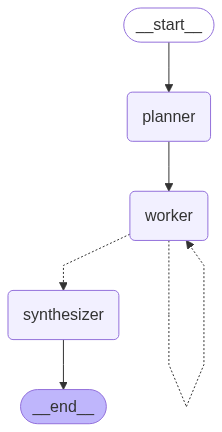

In [2]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))